## Setting up datasetpath for Anchor, Negative, and Positive.

In [7]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


train_dir = Path("../../../data/datasets/face_data/classification_data/train_data")

person_folders = [folder for folder in train_dir.iterdir() if folder.is_dir()]

print("Number of identities:", len(person_folders))

image_counts = []

for person_folder in person_folders:
    images = list(person_folder.glob("*"))
    image_counts.append((person_folder.name, len(images)))

image_counts_sorted = sorted(image_counts, key=lambda x: x[1])

print("Smallest 10 identities:")
for person_id, count in image_counts_sorted[:10]:
    print(person_id, count)

print("\nLargest 10 identities:")
for person_id, count in image_counts_sorted[-10:]:
    print(person_id, count)


valid_person_folders = []
for person_folder in person_folders:
    images = list(person_folder.glob("*"))

    if len(images) >= 2:
        valid_person_folders.append(person_folder)

print("valid identities for triplet training", len(valid_person_folders))

Number of identities: 4000
Smallest 10 identities:
n001967 15
n004423 19
n008469 20
n005193 21
n003208 21
n008081 22
n003084 23
n006105 24
n005521 25
n001881 26

Largest 10 identities:
n004093 207
n007590 208
n002165 212
n000812 213
n000633 213
n004844 214
n007120 220
n005018 221
n000419 225
n001586 249
valid identities for triplet training 4000


In [8]:
#creating the Anchor image , positive image, and negative image,

def get_image_paths(person_folder):
    image_extensions = ["*.jpg", "*.jpeg", "*.png"]

    image_paths = []

    for extension in image_extensions:
        image_paths.extend(list(person_folder.glob(extension)))

    return image_paths

In [9]:
#Generating triplet set
def generate_triplet(valid_person_folders):
    #select random achor person
    anchor_person = random.choice(valid_person_folders)
    #select negative person
    negative_person = random.choice(valid_person_folders)
    # functionality to check if they are same on chance 

    while negative_person == anchor_person:
        negative_person = random.choice(valid_person_folders)

    anchor_positive_images = get_image_paths(anchor_person)
    negative_images = get_image_paths(negative_person)


    anchor_path, positive_path = random.sample(anchor_positive_images, 2)

    negative_path = random.choice(negative_images)

    return anchor_path, positive_path, negative_path

anchor_path, positive_path, negative_path = generate_triplet(valid_person_folders)

print("Anchor: ", anchor_path)
print("Positive:", positive_path)
print("Negative:", negative_path)

print("\nAnchor identity:", anchor_path.parent.name)
print("Positive identity:", positive_path.parent.name)
print("Negative identity:", negative_path.parent.name)


Anchor:  ../../../data/datasets/face_data/classification_data/train_data/n005618/0165_01.jpg
Positive: ../../../data/datasets/face_data/classification_data/train_data/n005618/0110_01.jpg
Negative: ../../../data/datasets/face_data/classification_data/train_data/n003175/0322_01.jpg

Anchor identity: n005618
Positive identity: n005618
Negative identity: n003175


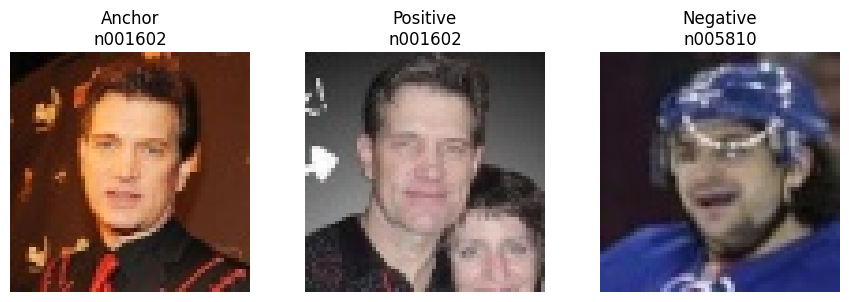

In [11]:
#OPTIONALLY display images of triplet set for verification
def show_triplet(anchor_path, positive_path, negative_path):
    anchor_img = Image.open(anchor_path)
    positive_img = Image.open(positive_path)
    negative_img = Image.open(negative_path)

    plt.figure(figsize=(9, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(anchor_img)
    plt.title(f"Anchor\n{anchor_path.parent.name}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(positive_img)
    plt.title(f"Positive\n{positive_path.parent.name}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(negative_img)
    plt.title(f"Negative\n{negative_path.parent.name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


anchor_path, positive_path, negative_path = generate_triplet(valid_person_folders)
show_triplet(anchor_path, positive_path, negative_path)


In [12]:
# IMAGE PREPROCESSESING
IMAGE_SIZE = (160, 160)
def load_and_preprocess_image(image_path):
    #load the image from its file path
    image= Image.open(image_path)

    #makes sure each image has 3 colour channels
    image = image.convert("RGB")
    
    #resize images to be 160x160
    image = image.resize(IMAGE_SIZE)

    #converts image into numbers
    image_array = np.array(image)

    #converts pixel numbers to decimal for tensorflow
    image_array = image_array.astype("float32")

    #normalize pixel range from 0-255 to 0.0 - 1.0
    image_array = image_array / 255.0

    return image_array

anchor_img = load_and_preprocess_image(anchor_path)
positive_img = load_and_preprocess_image(positive_path)
negative_img = load_and_preprocess_image(negative_path)

print("Anchor image shape:", anchor_img.shape)
print("Positive image shape:", positive_img.shape)
print("Negative image shape:", negative_img.shape)

print("Anchor min pixel value:", anchor_img.min())
print("Anchor max pixel value:", anchor_img.max())

Anchor image shape: (160, 160, 3)
Positive image shape: (160, 160, 3)
Negative image shape: (160, 160, 3)
Anchor min pixel value: 0.0
Anchor max pixel value: 1.0
